In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
from functools import partial

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxpower import BinMesh2SpectrumPoles, FKPField, ParticleField, compute_fkp2_normalization, get_mesh_attrs
from jaxpower.mesh import _get_extent
from lsstypes import cov, mean, read
from tqdm import tqdm

from desiforwardwindow.convenience import fiducial_planck_2018, get_randoms
from desiforwardwindow.forward import get_AIC_foward_model, get_RIC_forward_model, mock_survey, mock_survey_diff
from desiforwardwindow.window import get_window_geometry, get_window_spikes


Example of computing the Y3 window, with RIC and AIC for LRG SGC.

# Parameter choices

In [4]:
LOS = "local"
UNITARY_AMPLITUDE = True
BATCH_SIZE = 1

regression_maps = ['STARDENS','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','GALDEPTH_G','GALDEPTH_R','GALDEPTH_Z','EBV_DIFF_GR','EBV_DIFF_RZ','HI'] # will need to create some of those, not stored

n_bins_AIC = 10 # template bins for the regression
n_bins_RIC = 1000 # distance bins for the shells in RIC

# Data preparation

## Read randoms from disk

In [5]:
tracer = "LRG"
positions, stored_weights = get_randoms(n_randoms=5, region="SGC", zrange=(0.4, 1.1), tracer=tracer, weight_type="default")
boxsize = jnp.array([8000.0, 8000.0, 8000.0])
cellsize = 50.
#data_size = 1677566 # amount of data in the corresponding data catalog
data_size = positions.shape[0] // 2

stored_weights = stored_weights[0]

## Get systematics information

In [6]:
import fitsio
import healpy as hp
import LSS.common_tools as common
from numpy.lib.recfunctions import append_fields, structured_to_unstructured

debv = common.get_debv()

sys_tab = fitsio.read(f"/dvs_ro/cfs/cdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v2/hpmaps/{tracer}_mapprops_healpix_nested_nside256_S.fits")

for col in regression_maps:
    if "DEPTH" in col:
        bnd = col.split("_")[-1]
        sys_tab[col] *= 10 ** (-0.4 * common.ext_coeff[bnd] * sys_tab["EBV"])
sys_tab = append_fields(sys_tab, names=["EBV_DIFF_" + ec for ec in ["GR", "RZ"]], data=[debv["EBV_DIFF_" + ec] for ec in ["GR", "RZ"]], usemask=False)

hpx_rand = hp.vec2pix(nside=256, x=positions[:, 0], y=positions[:, 1], z=positions[:, 2], nest=True)
template_values = structured_to_unstructured(sys_tab[regression_maps][hpx_rand]).astype(float)

del sys_tab, hpx_rand, debv

## Designate "data" and randoms

In [7]:
seed = jax.random.key(42)
data_indices_in_randoms = jax.random.choice(key=seed, a=stored_weights.size, shape=[data_size], replace=False).astype(int)
mask_is_data = jnp.zeros_like(stored_weights, dtype=bool).at[data_indices_in_randoms].set(True)
mask_is_randoms = jnp.invert(mask_is_data)

Start by pre-computing everything that can be, and defining some jitted, differentiable functions that simply take in the data weights and return forward modeling ones.

`get_AIC_foward_model` can be quite long due to some hefty operations on the randoms.

In [8]:
pos_min, pos_max = _get_extent(positions)
boxcenter = 0.5 * (pos_min + pos_max)

In [9]:
get_RIC_weights = get_RIC_forward_model(data_positions=positions[mask_is_data], randoms_positions=positions[mask_is_randoms], randoms_weights=stored_weights[mask_is_randoms], boxcenter=boxcenter, boxsize=boxsize, n_bins_RIC=n_bins_RIC)
get_AIC_weights = get_AIC_foward_model(data_weights=stored_weights[mask_is_data], randoms_weights=stored_weights[mask_is_randoms], template_values=template_values, mask_is_data=mask_is_data, n_bins=n_bins_AIC)

In [10]:
mattrs = get_mesh_attrs(positions, cellsize=cellsize, boxsize=boxsize, check=True)  # [8000.0, 16000.0, 8000.0], check=True)
# Can pre-paint the randoms, since they won't move. Can't paint data.
randoms = ParticleField(positions[~mask_is_data], weights=stored_weights[~mask_is_data], attrs=mattrs, exchange=True)
randoms_mesh = randoms.paint(resampler="tsc", interlacing=3, compensate=True)
randoms_shotnoise = (randoms.weights**2).sum()
data = ParticleField(positions[mask_is_data], weights=stored_weights[mask_is_data], attrs=mattrs, exchange=True)

del positions, stored_weights

## Details for P(k) computation

In [11]:
# To go from the mesh to the observed power spectrum
# Can always rebin ell = 2 to 0.002 later
binner = BinMesh2SpectrumPoles(randoms.attrs, edges={"step": 0.001}, ells=(0, 2, 4))

# Precompute the FKP power spectrum norm, without accounting for future data painting
FKP_field = FKPField(data=data, randoms=randoms)
fkp_norm = compute_fkp2_normalization(FKP_field, bin=binner, cellsize=10.)
del FKP_field

# Fiducial theory

In [12]:
theory = fiducial_planck_2018(jnp.arange(0.0, mattrs.knyq.max(), 0.001)) # Stop at the selection's k_nyq

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/code/cosmoprimo/main/lib/python3.10/site-packages/cosmoprimo/eisenstein_hu.py:25: UserWarning: EisensteinHuEngine cannot cope with massive neutrinos
  warnings.warn('{} cannot cope with massive neutrinos'.format(self.__class__.__name__))


# Window computation

## Setup forward modeling

In [13]:
forward_model_pk = jax.jit(
    partial(
        mock_survey,
        theory=theory,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        binner=binner,
        randoms_shotnoise=randoms_shotnoise,
        fkp_norm=fkp_norm,
    ),
    static_argnames=["get_RIC_weights", "get_AIC_weights"],
)
# left: seed, data, randoms_mesh, get_AIC_weights, get_RIC_weights

In [14]:
nreal_fw = 1000
pks_geo = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=None, get_AIC_weights=None) for seed in tqdm(range(nreal_fw))]
pks_ARIC = [forward_model_pk(seed=jax.random.key(seed), data=data, randoms_mesh=randoms_mesh, get_RIC_weights=get_RIC_weights, get_AIC_weights=get_AIC_weights) for seed in tqdm(range(nreal_fw))]

100%|██████████| 1000/1000 [05:48<00:00,  2.87it/s]


In [15]:
pks_geo_mean = mean(pks_geo)
pks_geo_cov = cov(pks_geo)
pks_ARIC_mean = mean(pks_ARIC)
pks_ARIC_cov = cov(pks_ARIC)

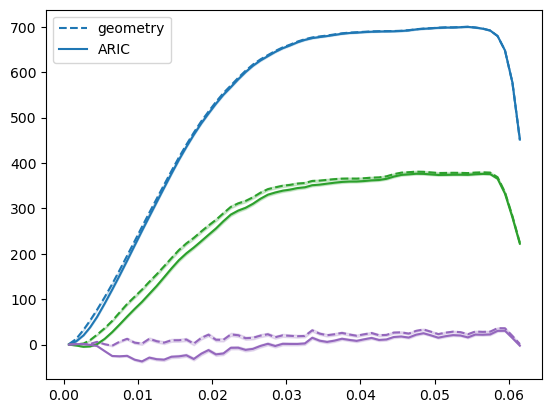

In [16]:
for ell in [0, 2, 4]:
    color = f"C{ell}"
    pole = pks_geo_mean.get(ell)
    std = pks_geo_cov.at.observable.get(ell).std() / jnp.sqrt(nreal_fw)
    plt.plot(pole.coords('k'), pole.coords('k')*pole.value(), color=color, ls="--", label="geometry")
    plt.fill_between(pole.coords('k'),
                     pole.coords('k')*(pole.value()-std),
                     pole.coords('k')*(pole.value()+std),
                     color=color, alpha=0.2)
    
    pole = pks_ARIC_mean.get(ell)
    std = pks_ARIC_cov.at.observable.get(ell).std() / jnp.sqrt(nreal_fw)
    plt.plot(pole.coords('k'), pole.coords('k')*pole.value(), color=color, ls="-", label="ARIC")
    plt.fill_between(pole.coords('k'),
                     pole.coords('k')*(pole.value()-std),
                     pole.coords('k')*(pole.value()+std),
                     color=color, alpha=0.2)
    if ell == 0:
        plt.legend()
    

## Geometry analytical estimation

In [17]:
window_geo = get_window_geometry(selection=data.sum()/randoms.sum() * randoms_mesh, # tsc
                                     theory_edges=theory,
                                     theory_ells=theory.ells, 
                                     binner=binner, 
                                     norm=fkp_norm, # cic
                                     flags=(), 
                                     los=LOS, 
                                     pbar=True)

100%|█████████▉| 62/62 [01:53<00:00,  1.83s/it]


## Control variate on IC

In [18]:
window_cv, windows_cv = get_window_spikes(
    mock_survey=mock_survey_diff, 
    theory=theory, 
    nreal=2, 
    seeds=None, 
    batch_size=1, 
    mock_survey_kw={
        "data":data,
        "binner":binner,
        "los":LOS,
        "unitary_amplitude":UNITARY_AMPLITUDE,
        "randoms_shotnoise":randoms_shotnoise,
        "randoms_mesh":randoms_mesh,
        "fkp_norm":fkp_norm,
        "get_RIC_weights":get_RIC_weights,
        "get_AIC_weights":get_AIC_weights,
    },
    unhashable=["data", "binner", "randoms_shotnoise", "randoms_mesh", "fkp_norm"],
)

['mock_survey', 'los', 'get_RIC_weights', 'unitary_amplitude', 'get_AIC_weights']


100%|██████████| 186/186 [04:29<00:00,  1.45s/it]


In [19]:
window = window_cv.clone(value=(window_cv.value() + window_geo.value()))
windows = [wd_cv.clone(value=(wd_cv.value() + window_geo.value())) for wd_cv in windows_cv]

In [20]:
windowed_theory = window.dot(theory, return_type=None, zpt=False)
windowed_theories = [wd.dot(theory, return_type=None, zpt=False) for wd in windows]
windowed_theory_mean = mean(windowed_theories)
windowed_theory_cov = cov(windowed_theories)

/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250526-1.0.0/conda/lib/python3.10/site-packages/numpy/ma/core.py:2820: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.02, 0.5, '$k(W(k, q)P_\\ell(q) - P_\\ell^\\mathrm{obs}(k))$')

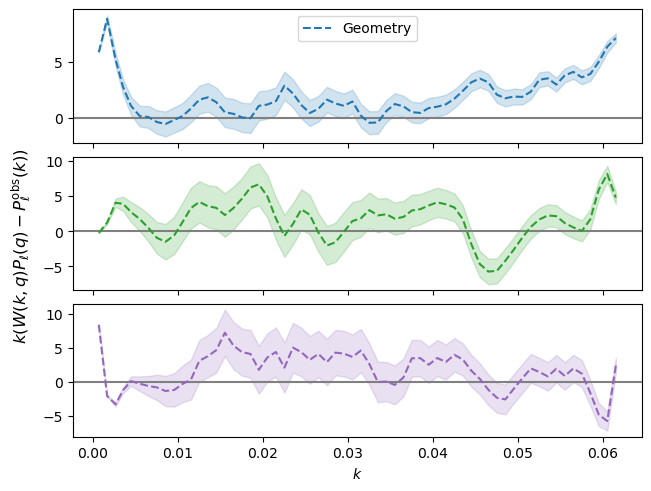

In [21]:
fig, lax = plt.subplots(3, 1, layout="constrained", sharex=True)

for ell in [0, 2, 4]:
    lax[ell//2].axhline(0, color="gray")
    color = f"C{ell}"
    pole_theo_all = windowed_theory_mean.get(ell)
    pole_theo_geo = window_geo.dot(theory, return_type=None, zpt=False).get(ell)
    
    std = windowed_theory_cov.at.observable.get(ell).std().real/jnp.sqrt(2)

    pole_all = pks_ARIC_mean.get(ell)
    pole_geo = pks_geo_mean.get(ell)
    
    #lax[ell//2].plot(pole_theo_all.coords('k'), pole_theo_all.coords('k')**0 * (pole_theo_all.value() - pole_all.value()), color=color, ls='-', label="All")
    #lax[ell//2].fill_between(
        #pole_theo_all.coords('k'),
        #pole_theo_all.coords('k') * (pole_theo_all.value() - pole_all.value() - std),
        #pole_theo_all.coords('k') * (pole_theo_all.value() - pole_all.value() + std),
        #color=color, alpha=0.2)
    std_fw_geo = pks_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(nreal_fw)
    lax[ell//2].plot(pole_theo_geo.coords('k'), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value()), color=color, ls='--', label="Geometry")
    lax[ell//2].fill_between(pole_theo_geo.coords('k'),
                             pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value() - std_fw_geo),
                             pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value() + std_fw_geo),
                             color=color, alpha=0.2)
    

lax[0].legend()
plt.xlabel("$k$")
fig.supylabel(r"$k(W(k, q)P_\ell(q) - P_\ell^\mathrm{obs}(k))$")

Text(0.02, 0.5, '$k(W(k, q)P_\\ell(q) - P_\\ell^\\mathrm{obs}(k))$')

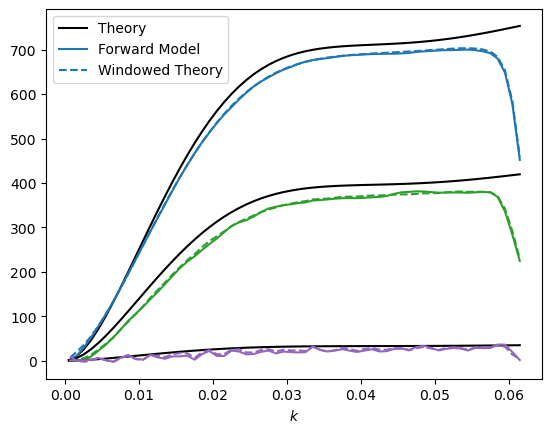

In [22]:
for ell in [0, 2, 4]:
    color = f"C{ell}"
    pole_theo = theory.get(ell)
    
    plt.plot(pole_theo.coords('k'),
             pole_theo.coords('k') * pole_theo.value(),
             color='k', ls='-', label="Theory")
    
    pole_theo_geo = window_geo.dot(theory, return_type=None, zpt=False).get(ell)

    pole_geo = pks_geo_mean.get(ell)
    
    plt.plot(pole_geo.coords('k'),
             pole_geo.coords('k') * pole_geo.value(),
             color=color, ls='-', label="Forward Model")

    plt.plot(pole_theo_geo.coords('k'),
             pole_theo_geo.coords('k') * pole_theo_geo.value(),
             color=color, ls='--', label="Windowed Theory")
    if ell == 0:
        plt.legend()
plt.xlabel("$k$")
fig.supylabel(r"$k(W(k, q)P_\ell(q) - P_\ell^\mathrm{obs}(k))$")

# Check against mesh-based geometry FM

In [23]:
from desiforwardwindow.forward import mock_survey_mesh

In [24]:
forward_model_mesh = jax.jit(
    partial(
        mock_survey_mesh,
        theory=theory,
        los=LOS,
        unitary_amplitude=UNITARY_AMPLITUDE,
        binner=binner,
        ric=False,
    ),
)
# left: seed, data, randoms_mesh, get_AIC_weights, get_RIC_weights

In [25]:
pks_geo_mesh = [
    forward_model_mesh(seed=jax.random.key(seed), selection=data.sum()/randoms.sum() * randoms_mesh, norm=fkp_norm) 
    for seed in tqdm(range(nreal_fw))
]

100%|██████████| 1000/1000 [00:48<00:00, 20.78it/s]


In [26]:
pks_geo_mesh_mean = mean(pks_geo_mesh)
pks_geo_mesh_cov = cov(pks_geo_mesh)

Text(0.5, 0.98, 'Analytical window-FW agreement for 1000 realisations')

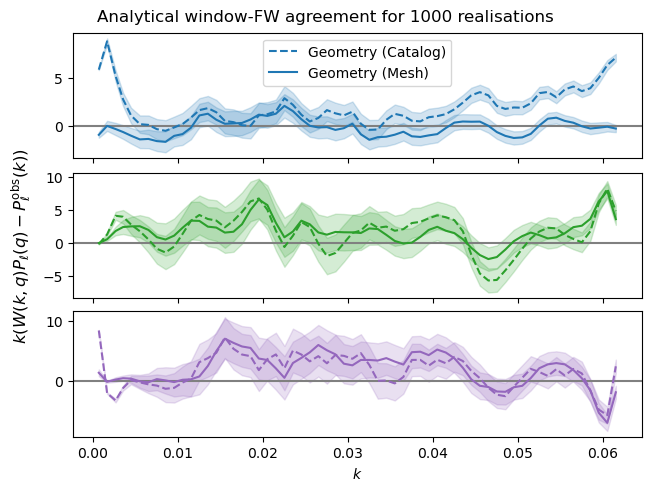

In [28]:
fig, lax = plt.subplots(3, 1, layout="constrained", sharex=True)

for ell in [0, 2, 4]:
    lax[ell//2].axhline(0, color="gray")
    color = f"C{ell}"
    pole_theo_geo = window_geo.dot(theory, return_type=None, zpt=False).get(ell)

    pole_geo = pks_geo_mean.get(ell)
    std_geo = pks_geo_cov.at.observable.get(ell).std().real / jnp.sqrt(1000)
    lax[ell//2].plot(pole_theo_geo.coords('k'), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value()), color=color, ls='--', label="Geometry (Catalog)")
    lax[ell//2].fill_between(pole_theo_geo.coords('k'), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value() - std_geo), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value() + std_geo), color=color, alpha=0.2)

    pole_geo = pks_geo_mesh_mean.get(ell)
    std_geo = pks_geo_mesh_cov.at.observable.get(ell).std().real / jnp.sqrt(1000)
    lax[ell//2].plot(pole_theo_geo.coords('k'), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value()), color=color, ls='-', label="Geometry (Mesh)")
    lax[ell//2].fill_between(pole_theo_geo.coords('k'), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value() - std_geo), pole_theo_geo.coords('k') * (pole_theo_geo.value() - pole_geo.value() + std_geo), color=color, alpha=0.2)


lax[0].legend()
plt.xlabel("$k$")
fig.supylabel(r"$k(W(k, q)P_\ell(q) - P_\ell^\mathrm{obs}(k))$")
fig.suptitle(f"Analytical window-FW agreement for {nreal_fw} realisations")